##  Project Title: Amazon Sales Data Analysis 


##  Introduction

This project focuses on analyzing Amazon sales data to uncover meaningful insights related to sales performance, customer behavior, product trends, and operational efficiency. The dataset consists of transaction-level information including order details, product categories, fulfillment methods, and geographical data. Through data cleaning, preprocessing, and exploratory data analysis (EDA), the project aims to transform raw data into actionable insights that can support business decision-making.

---

##  Objective  

- To analyze overall sales performance and identify trends over time  
- To evaluate product category performance and identify top-selling items  
- To examine customer purchasing behavior across different days  
- To explore geographical distribution of sales across states and cities  
- To assess operational efficiency through order status and cancellation analysis  
- To provide actionable business recommendations based on insights  

## Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Optional (for better visuals)
sns.set(style="whitegrid")

# Step 2: Load Dataset
df = pd.read_csv("Amazon Sale Report.csv")

# Step 3: Preview Data
df.head()

,index,Order ID,Date,Status,Fulfilment,Sales Channel,ship-service-level,Category,Size,Courier Status,...,currency,Amount,ship-city,ship-state,ship-postal-code,ship-country,B2B,fulfilled-by,New,PendingS
0,0,405-8078784-5731545,04-30-22,Cancelled,Merchant,Amazon.in,Standard,T-shirt,S,On the Way,...,INR,647.62,MUMBAI,MAHARASHTRA,400081.0,IN,False,Easy Ship,NaN,NaN
1,1,171-9198151-1101146,04-30-22,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,Shirt,3XL,Shipped,...,INR,406.00,BENGALURU,KARNATAKA,560085.0,IN,False,Easy Ship,NaN,NaN
2,2,404-0687676-7273146,04-30-22,Shipped,Amazon,Amazon.in,Expedited,Shirt,XL,Shipped,...,INR,329.00,NAVI MUMBAI,MAHARASHTRA,410210.0,IN,True,NaN,NaN,NaN
3,3,403-9615377-8133951,04-30-22,Cancelled,Merchant,Amazon.in,Standard,Blazzer,L,On the Way,...,INR,753.33,PUDUCHERRY,PUDUCHERRY,605008.0,IN,False,Easy Ship,NaN,NaN
4,4,407-1069790-7240320,04-30-22,Shipped,Amazon,Amazon.in,Expedited,Trousers,3XL,Shipped,...,INR,574.00,CHENNAI,TAMIL NADU,600073.0,IN,False,NaN,NaN,NaN


## Data Cleaning and Preprocessing

In [2]:
df.shape

(128976, 21)

In [3]:
df.columns

Index(['index', 'Order ID', 'Date', 'Status', 'Fulfilment', 'Sales Channel',
       'ship-service-level', 'Category', 'Size', 'Courier Status', 'Qty',
       'currency', 'Amount', 'ship-city', 'ship-state', 'ship-postal-code',
       'ship-country', 'B2B', 'fulfilled-by', 'New', 'PendingS'],
      dtype='object')

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 128976 entries, 0 to 128975
Data columns (total 21 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   index               128976 non-null  int64  
 1   Order ID            128976 non-null  object 
 2   Date                128976 non-null  object 
 3   Status              128976 non-null  object 
 4   Fulfilment          128976 non-null  object 
 5   Sales Channel       128976 non-null  object 
 6   ship-service-level  128976 non-null  object 
 7   Category            128976 non-null  object 
 8   Size                128976 non-null  object 
 9   Courier Status      128976 non-null  object 
 10  Qty                 128976 non-null  int64  
 11  currency            121176 non-null  object 
 12  Amount              121176 non-null  float64
 13  ship-city           128941 non-null  object 
 14  ship-state          128941 non-null  object 
 15  ship-postal-code    128941 non-nul

In [5]:
df.isnull().sum()

index                      0
Order ID                   0
Date                       0
Status                     0
Fulfilment                 0
Sales Channel              0
ship-service-level         0
Category                   0
Size                       0
Courier Status             0
Qty                        0
currency                7800
Amount                  7800
ship-city                 35
ship-state                35
ship-postal-code          35
ship-country              35
B2B                        0
fulfilled-by           89713
New                   128976
PendingS              128976
dtype: int64

In [6]:
df.describe()

,index,Qty,Amount,ship-postal-code,New,PendingS
count,128976.000000,128976.000000,121176.000000,128941.000000,0.0,0.0
mean,64486.130427,0.904401,648.562176,463945.677744,NaN,NaN
std,37232.897832,0.313368,281.185041,191458.488954,NaN,NaN
min,0.000000,0.000000,0.000000,110001.000000,NaN,NaN
25%,32242.750000,1.000000,449.000000,382421.000000,NaN,NaN
50%,64486.500000,1.000000,605.000000,500033.000000,NaN,NaN
75%,96730.250000,1.000000,788.000000,600024.000000,NaN,NaN
max,128974.000000,15.000000,5584.000000,989898.000000,NaN,NaN


In [7]:
# Drop useless columns
df = df.drop(columns=['New', 'PendingS', 'fulfilled-by', 'index'])

# Drop rows with missing shipping info (very few rows)
df = df.dropna(subset=['ship-city', 'ship-state', 'ship-postal-code', 'ship-country'])

# Drop rows where Amount is missing (important column)
df = df.dropna(subset=['Amount'])

# Check again
df.isnull().sum()

Order ID              0
Date                  0
Status                0
Fulfilment            0
Sales Channel         0
ship-service-level    0
Category              0
Size                  0
Courier Status        0
Qty                   0
currency              0
Amount                0
ship-city             0
ship-state            0
ship-postal-code      0
ship-country          0
B2B                   0
dtype: int64

In [8]:
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_").str.replace("-", "_")
df.columns

Index(['order_id', 'date', 'status', 'fulfilment', 'sales_channel',
       'ship_service_level', 'category', 'size', 'courier_status', 'qty',
       'currency', 'amount', 'ship_city', 'ship_state', 'ship_postal_code',
       'ship_country', 'b2b'],
      dtype='object')

In [9]:
df['date'] = pd.to_datetime(df['date'], format='mixed')

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 121143 entries, 0 to 128975
Data columns (total 17 columns):
 #   Column              Non-Null Count   Dtype         
---  ------              --------------   -----         
 0   order_id            121143 non-null  object        
 1   date                121143 non-null  datetime64[ns]
 2   status              121143 non-null  object        
 3   fulfilment          121143 non-null  object        
 4   sales_channel       121143 non-null  object        
 5   ship_service_level  121143 non-null  object        
 6   category            121143 non-null  object        
 7   size                121143 non-null  object        
 8   courier_status      121143 non-null  object        
 9   qty                 121143 non-null  int64         
 10  currency            121143 non-null  object        
 11  amount              121143 non-null  float64       
 12  ship_city           121143 non-null  object        
 13  ship_state          121143 non-nul

In [11]:
df['date'].head(10)

0    2022-04-30
1    2022-04-30
2    2022-04-30
3    2022-04-30
4    2022-04-30
5    2022-04-30
6    2022-04-30
7    2022-04-30
9    2022-04-30
10   2022-04-30
Name: date, dtype: datetime64[ns]

In [12]:
df['status'].value_counts()

status
Shipped                          77589
Shipped - Delivered to Buyer     28741
Cancelled                        10758
Shipped - Returned to Seller      1948
Shipped - Picked Up                973
Pending                            656
Pending - Waiting for Pick Up      281
Shipped - Returning to Seller      145
Shipped - Out for Delivery          35
Shipped - Rejected by Buyer         11
Shipped - Lost in Transit            5
Shipped - Damaged                    1
Name: count, dtype: int64

In [13]:
df_full = df.copy()

In [14]:
valid_status = ['Shipped', 'Shipped - Delivered to Buyer']

df = df[df['status'].isin(valid_status)].copy()

In [15]:
df['status'].value_counts()
df.shape

(106330, 17)

In [16]:
df.describe()

,date,qty,amount,ship_postal_code
count,106330,106330.000000,106330.000000,106330.000000
mean,2022-05-11 19:51:31.063669760,1.003564,648.515057,462090.551867
min,2022-03-31 00:00:00,1.000000,0.000000,110001.000000
25%,2022-04-20 00:00:00,1.000000,449.000000,382421.000000
50%,2022-05-09 00:00:00,1.000000,599.000000,500028.000000
75%,2022-06-03 00:00:00,1.000000,788.000000,600010.000000
max,2022-06-29 00:00:00,8.000000,5584.000000,855117.000000
std,NaN,0.070976,282.756256,190546.704760


In [17]:
df = df[df['amount'] > 0]

In [18]:
df.describe()

,date,qty,amount,ship_postal_code
count,104096,104096.000000,104096.000000,104096.000000
mean,2022-05-11 18:46:28.810329344,1.003641,662.432812,462649.506350
min,2022-03-31 00:00:00,1.000000,199.000000,110001.000000
25%,2022-04-20 00:00:00,1.000000,459.000000,382449.750000
50%,2022-05-09 00:00:00,1.000000,618.000000,500030.000000
75%,2022-06-03 00:00:00,1.000000,788.000000,600011.000000
max,2022-06-29 00:00:00,8.000000,5584.000000,855117.000000
std,NaN,0.071732,269.160320,190329.880022


In [19]:
df['month_name'] = df['date'].dt.month_name()
df['day'] = df['date'].dt.day
df['day_name'] = df['date'].dt.day_name()

## Visualizations

## Monthly Sales Trend

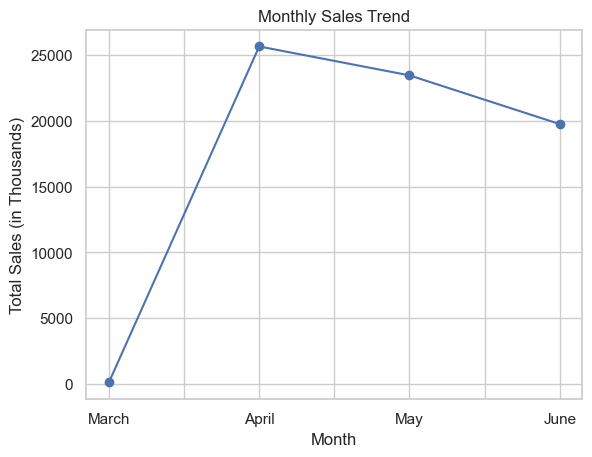

In [20]:
monthly_sales = df.groupby('month_name')['amount'].sum()

# Correct order
order = ['March', 'April', 'May', 'June']
monthly_sales = monthly_sales.reindex(order)

# Scale
monthly_sales = monthly_sales / 1000

# Plot
monthly_sales.plot(kind='line', marker='o')
plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Total Sales (in Thousands)')
plt.show()

### Insights  
April recorded the highest sales, making it the peak month.  
Sales declined after April, indicating a slowdown.  
March showed steady growth, leading into April’s peak.

## Sales By Category

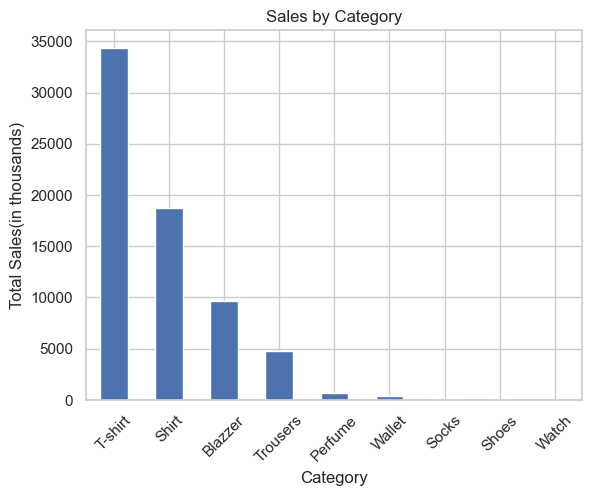

In [21]:
category_sales = df.groupby('category')['amount'].sum().sort_values(ascending=False)
category_sales = category_sales / 1000
category_sales.plot(kind='bar')
plt.title('Sales by Category')
plt.xlabel('Category')
plt.ylabel('Total Sales(in thousands)')
plt.xticks(rotation=45)
plt.show()

### Insights  
T-shirts dominate sales, contributing the highest revenue by a large margin.  
Shirts and Blazers follow, but significantly behind T-shirts. 
Trousers show moderate performance, forming a mid-tier category.  
Accessories (Perfume, Wallet, Socks, Shoes, Watch) contribute very minimal sales, indicating low demand.

## Top 10 States by Sales

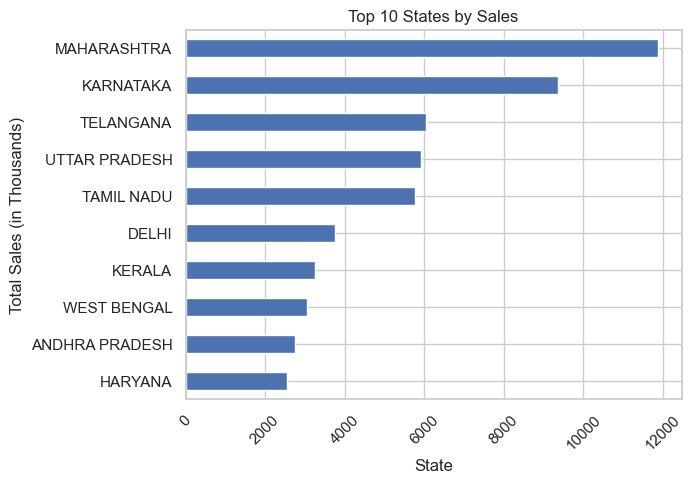

In [22]:
state_sales = df.groupby('ship_state')['amount'].sum().sort_values(ascending=False).head(10)

# Convert to thousands
state_sales = state_sales / 1000
state_sales.sort_values().plot(kind='barh')
plt.title('Top 10 States by Sales')
plt.xlabel('State')
plt.ylabel('Total Sales (in Thousands)')
plt.xticks(rotation=45)
plt.show()

### Insights  
Maharashtra leads sales, contributing the highest revenue among all states.  
Karnataka and Telangana follow, showing strong regional demand.  
Sales are well distributed, with several states contributing moderate revenue beyond the top performers.

## Orders by Day of Week

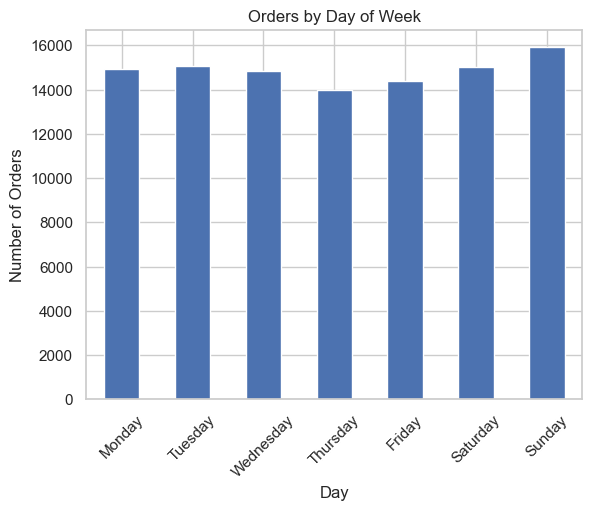

In [23]:
day_orders = df['day_name'].value_counts()

# Correct order of days
order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
day_orders = day_orders.reindex(order)

day_orders.plot(kind='bar')
plt.title('Orders by Day of Week')
plt.xlabel('Day')
plt.ylabel('Number of Orders')
plt.xticks(rotation=45)
plt.show()

### Insights  
Sunday records the highest orders, indicating peak customer activity.  
Thursday shows the lowest demand, reflecting a midweek dip.  
Other weekdays remain stable, with consistent order volume throughout the week.

## Orders by Fulfilment Type

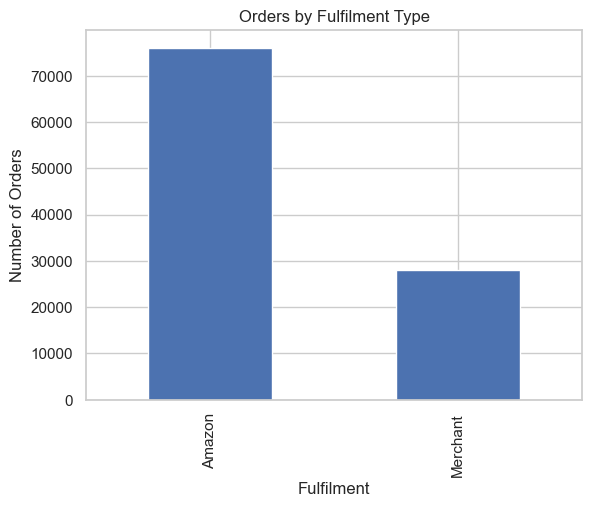

In [24]:
fulfilment_counts = df['fulfilment'].value_counts()

fulfilment_counts.plot(kind='bar')
plt.title('Orders by Fulfilment Type')
plt.xlabel('Fulfilment')
plt.ylabel('Number of Orders')
plt.show()

### Insights  
Amazon dominates fulfilment, handling the majority of both orders and sales.  
Merchant fulfilment plays a secondary role, contributing a smaller but significant share of orders and revenue.

## Sales By Fulfilment

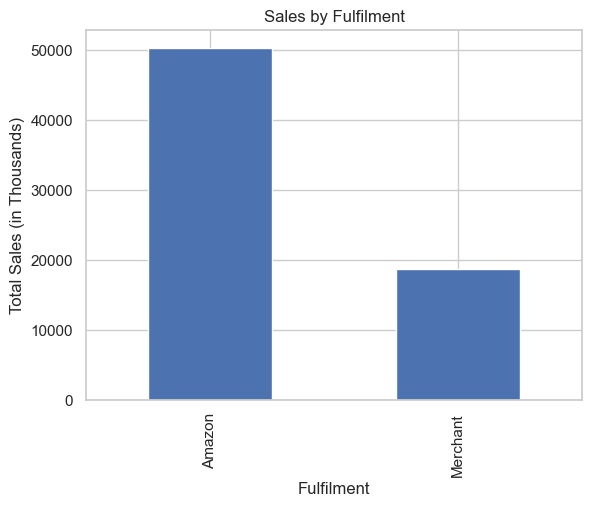

In [25]:
fulfilment_sales = df.groupby('fulfilment')['amount'].sum() / 1000

fulfilment_sales.plot(kind='bar')
plt.title('Sales by Fulfilment')
plt.xlabel('Fulfilment')
plt.ylabel('Total Sales (in Thousands)')
plt.show()

### Insights  
Sales distribution aligns with order volume, indicating Amazon’s stronger operational scale and reach.

## Order Status Distribution

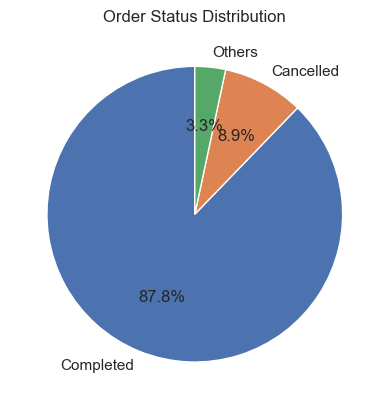

In [26]:
# Clean spaces
df_full['status'] = df_full['status'].str.strip()

# Create grouped status
df_full['Status_Group'] = df_full['status'].apply(
    lambda x: 'Completed' if x in ['Shipped', 'Shipped - Delivered to Buyer']
    else ('Cancelled' if x == 'Cancelled' else 'Others')
)

# Count and order
status_counts = df_full['Status_Group'].value_counts()
order = ['Completed', 'Cancelled', 'Others']
status_counts = status_counts.reindex(order)

# Plot pie chart
status_counts.plot(kind='pie', autopct='%1.1f%%', startangle=90)
plt.title('Order Status Distribution')
plt.ylabel('')
plt.show()

### Insights  
High completion rate, with the majority of orders successfully fulfilled.  
Low cancellation rate, indicating efficient operations and good customer experience.  
Minimal exceptional cases, showing that irregular order statuses are rare.

## Cancellation Rate

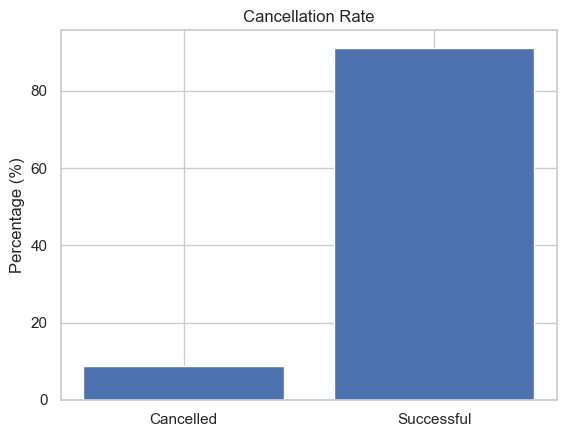

In [27]:
cancel_rate = (df_full['status'] == 'Cancelled').mean() * 100

labels = ['Cancelled', 'Successful']
values = [cancel_rate, 100 - cancel_rate]

plt.bar(labels, values)
plt.title('Cancellation Rate')
plt.ylabel('Percentage (%)')
plt.show()

### Insights  
Low cancellation rate (<20%), indicating efficient order management.  
High success rate (>80%), reflecting strong fulfillment performance and customer satisfaction.

## Top 5 cities by sales

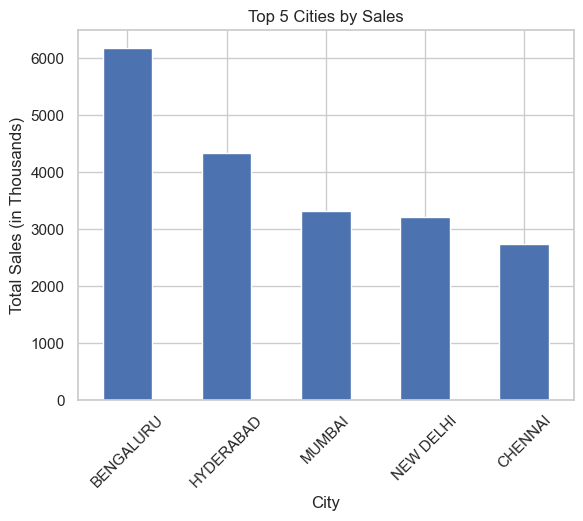

In [28]:
city_sales = df.groupby('ship_city')['amount'].sum().sort_values(ascending=False).head(5) / 1000

city_sales.plot(kind='bar')
plt.title('Top 5 Cities by Sales')
plt.xlabel('City')
plt.ylabel('Total Sales (in Thousands)')
plt.xticks(rotation=45)
plt.show()

### Insights  
Bengaluru leads sales, emerging as the top-performing city.  
Hyderabad and Mumbai follow, showing strong demand in major metro regions.  
Delhi and Chennai contribute steadily, indicating a well-distributed urban customer base.

## Key Insights

### Sales Trends  
April recorded the highest sales, making it the peak month.  
Sales declined after April, indicating a slowdown.  
March showed steady growth, leading into April’s peak.

### Product Analysis  
T-shirts dominate sales, contributing the highest revenue.  
Shirts and Blazers follow, but significantly behind.  
Accessories contribute minimal sales, indicating low demand.

### Geographical Insights  
Maharashtra leads sales among all states.  
Karnataka and Telangana follow as strong markets.  
Metro cities like Bengaluru, Hyderabad, and Mumbai dominate sales.

### Customer Behavior  
Sunday has the highest orders, showing peak activity.  
Thursday shows lowest engagement, indicating a midweek dip.  
Other days remain stable, reflecting consistent demand.

### Operational Insights  
High completion rate (>85%), showing efficient fulfillment.  
Low cancellation rate (<15%), indicating good customer satisfaction.  
Minimal exceptional cases, reflecting stable operations.

## BUSINESS RECOMMENDATIONS  
Focus on top-performing categories (T-shirts, Shirts) to maximize revenue  
Improve low-performing categories (accessories or niche products)  
Target high-performing regions (Maharashtra, Karnataka, Telangana)  
Run promotions on low-demand days (Thursday) to boost sales  
Maintain strong fulfillment processes to keep cancellations low

## CONCLUSION 
The business shows strong overall sales performance, driven by key product categories and regions.  
High order completion rate reflects efficient fulfillment and operational stability.  
Sales are concentrated in metro cities and top-performing states, indicating strong regional demand.  
Customer purchasing patterns show consistent demand with peak activity on specific days.  
There is scope for improvement in low-performing categories and midweek engagement strategies.